# **Import libraries**

In [ ]:
!pip install torchinfo
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 42.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import os

from scipy.signal import find_peaks
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import wfdb

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"


**LOAD DATASET & TIỀN XỬ LÝ DỮ LIỆU**

In [ ]:
# !wget -r -N -c -np https://physionet.org/files/mitdb/1.0.0/

In [ ]:
# import os
# ls = os.listdir('/content/physionet.org/files/mitdb/1.0.0')
# end_file = ('atr' , 'dat', 'hea' ,"xws")

# filered_files = [file for file in ls if file.endswith(end_file) ]

In [ ]:
# record_names = [100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 121, 122, 123, 124, 200, 201, 202, 203, 205, 207, 208, 209, 210, 212, 213, 214, 215, 217, 219, 220, 221, 222, 223, 228, 230, 231, 232, 233, 234]

In [ ]:
import wfdb
import numpy as np
import os
from scipy.signal import resample
from collections import Counter

def remove_outliers(rr_intervals):
    q1, q3 = np.percentile(rr_intervals, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return rr_intervals[(rr_intervals >= lower) & (rr_intervals <= upper)]

def extract_heartbeat(signal, peak, size):
    start = peak - size // 2
    end = peak + size // 2
    if start < 0 or end > len(signal):
        return None
    return signal[start:end]

def create_dataset(record_path, record_names, fs=360, global_size=450, new_fs=120):
    all_beats = []
    all_labels = []

    for rec in record_names:
        print(f"Processing record {rec}...")
        sig, fields = wfdb.rdsamp(os.path.join(record_path, rec))
        ecg = sig[:, 0]
        ann = wfdb.rdann(os.path.join(record_path, rec), 'atr')
        peaks = ann.sample
        symbols = ann.symbol

        win_size = fs * 10
        for start in range(0, len(ecg), win_size):
            end = min(len(ecg), start + win_size)
            window_peaks = [p for p in peaks if start < p < end]
            window_labels = [symbols[i] for i, p in enumerate(peaks) if start < p < end]

            if len(window_peaks) < 2:
                continue

            rr_in_window = np.diff(window_peaks) / fs
            if len(rr_in_window) == 0:
                continue

            hb_size = int(np.mean(rr_in_window) * fs)
            if hb_size < 50:
                continue

            for peak, sym in zip(window_peaks, window_labels):
                hb = extract_heartbeat(ecg, peak, hb_size)
                if hb is None:
                    continue
                if len(hb) < global_size:
                    hb = np.pad(hb, (0, global_size - len(hb)), 'constant')
                elif len(hb) > global_size:
                    hb = hb[:global_size]

                hb_down = resample(hb, int(global_size * new_fs / fs))

                hb_norm = (hb_down - np.mean(hb_down)) / (np.std(hb_down) + 1e-8)

                all_beats.append(hb_norm)
                all_labels.append(sym)

    X = np.array(all_beats)
    y = np.array(all_labels)
    print(f"Final dataset shape: {X.shape}, labels: {y.shape}")

    return X, y

record_path = '/content/physionet.org/files/mitdb/1.0.0/'
record_names = [
    100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
    111, 112, 113, 114, 115, 116, 117, 118, 119,
    121, 122, 123, 124,
    200, 201, 202, 203, 205, 207, 208, 209, 210,
    212, 213, 214, 215, 217, 219, 220, 221, 222, 223,
    228, 230, 231, 232, 233, 234
]
record_names = [str(r) for r in record_names]

X, y = create_dataset(record_path, record_names)

np.savez_compressed("mitbih_clean_dataset.npz", X=X, y=y)

# In phân bố class
counts = Counter(y)
print("Class distribution:")
for cls, cnt in counts.items():
    print(f"{cls}: {cnt}")


In [ ]:
import numpy as np
data = np.load("/content/mitbih_clean_dataset.npz", allow_pickle=True)

X = data["X"]
#y = data["y"]

print("X shape:", X.shape)
#print("y shape:", y.shape)
#print("Unique labels:", np.unique(y, return_counts=True))


X shape: (112521, 150)


In [ ]:
from collections import Counter
def map_symbol_to_group(sym):
    N_group = ['N', 'L', 'R', 'e', 'j']
    S_group = ['A', 'a', 'J', 'S']
    V_group = ['V', 'E']
    F_group = ['F']

    if sym in N_group:
        return 0
    elif sym in S_group:
        return 1
    elif sym in V_group:
        return 2
    elif sym in F_group:
        return 3
    else:
        return 4

grouped_segments = {0: [], 1: [], 2: [], 3: [], 4: []}

for hb, sym in zip(X, y):
    g = map_symbol_to_group(sym)
    grouped_segments[g].append(hb)

for g, beats in grouped_segments.items():
    print(f"Group {g}: {len(beats)} samples")

grouped_segments[0][0].shape

Group 0: 90569 samples
Group 1: 2781 samples
Group 2: 7230 samples
Group 3: 802 samples
Group 4: 11139 samples


(150,)

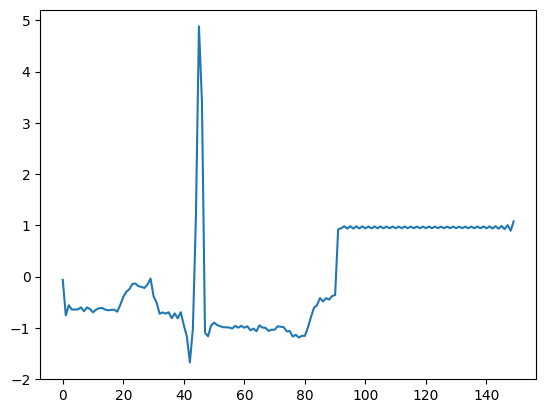

In [ ]:
plt.plot(grouped_segments[0][4]);

(150,)


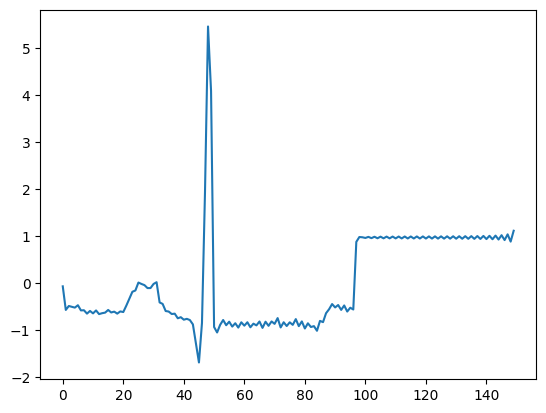

In [ ]:
plt.plot(grouped_segments[0][200]);
print(grouped_segments[0][200].shape)

**LOAD DATA | TRAIN MODEL**

In [ ]:
!unzip output_dir.zip

Archive:  output_dir.zip
   creating: content/qrs_segments/
  inflating: content/qrs_segments/label_4.npy  
  inflating: content/qrs_segments/label_2.npy  
  inflating: content/qrs_segments/label_1.npy  
  inflating: content/qrs_segments/label_0.npy  
  inflating: content/qrs_segments/label_3.npy  


In [ ]:
# def add_gaussian_noise(signal, mean=0, std=0.05):
#     noise = np.random.normal(mean, std, signal.shape)
#     return signal + noise
# def time_shift(signal, shift=10):
#     return np.roll(signal, shift)
# from scipy.interpolate import interp1d

# def time_stretch(signal, stretch_factor=1.1):
#     signal = np.asarray(signal).flatten()  # đảm bảo 1D
#     N = len(signal)

#     input_points = np.arange(N)
#     output_points = np.linspace(0, N - 1, int(N * stretch_factor))

#     f = interp1d(input_points, signal, kind='linear')
#     stretched_signal = f(output_points)

#     # Đảm bảo trả về đúng chiều dài gốc
#     if len(stretched_signal) > N:
#         return stretched_signal[:N]
#     else:
#         return np.pad(stretched_signal, (0, N - len(stretched_signal)), mode='edge')


# def frequency_shift(signal, shift=1):
#     freq_domain = np.fft.fft(signal)
#     shifted_signal = np.fft.ifft(np.roll(freq_domain, shift)).real
#     return shifted_signal

In [ ]:
label_0 = np.load('/content/content/qrs_segments/label_0.npy')
label_0.shape
example = label_0[0]
np.savetxt('/content/example_label_0.txt', example)

# **Dataset Pytorch & Dataloader**

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

class QRSLoader(Dataset):
    def __init__(self, grouped_segments, normalize=True, augment=False):
        self.data, self.labels = [], []
        self.normalize = normalize
        self.augment = augment

        for label, segments in grouped_segments.items():
            self.data.extend(segments)
            self.labels.extend([label] * len(segments))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sig = self.data[idx]
        label = self.labels[idx]

        if self.normalize:
            sig = (sig - np.min(sig)) / (np.max(sig) - np.min(sig) + 1e-6)
            sig = 2 * sig - 1

        sig = torch.tensor(sig, dtype=torch.float32).unsqueeze(0)  # (1, L)
        label = torch.tensor(label, dtype=torch.long)
        return sig, label

data_dir = "/content/content/qrs_segments"

full_dataset = QRSLoader(grouped_segments)

indices = np.arange(len(full_dataset))
labels = np.array(full_dataset.labels)

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices, labels, test_size=0.3, stratify=labels, random_state=42
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, labels[temp_idx], test_size=0.5, stratify=labels[temp_idx], random_state=42
)

train_set = Subset(full_dataset, train_idx)
val_set   = Subset(full_dataset, val_idx)
test_set  = Subset(full_dataset, test_idx)

train_set.dataset.augment = True
val_set.dataset.augment = False
test_set.dataset.augment = False

# ---------- Compute class weights ----------
train_labels = [full_dataset.labels[i] for i in train_idx]
classes = np.unique(train_labels)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Map label -> weight
class_to_weight = {c: w.item() for c, w in zip(classes, class_weights)}
sample_weights = [class_to_weight[label] for label in train_labels]

# ---------- DataLoaders ----------
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_set, batch_size=256, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_set, batch_size=256, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

signals, labels = next(iter(train_loader))
print("Signals:", signals.shape)  # [64, 1, L]
print("Labels:", labels.shape)    # [64]
print("Unique labels in batch:", labels.unique())


Signals: torch.Size([256, 1, 150])
Labels: torch.Size([256])
Unique labels in batch: tensor([0, 1, 2, 3, 4])


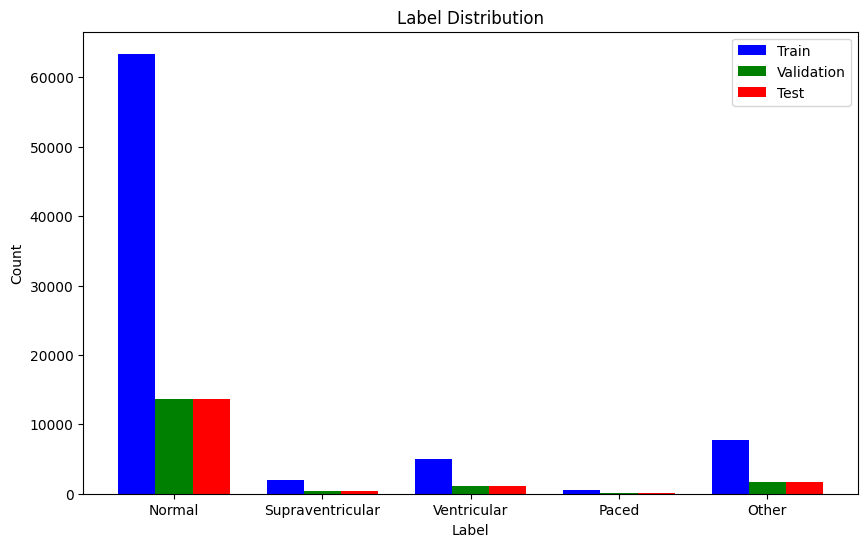

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

def get_labels(subset):
    return [subset.dataset.labels[i] for i in subset.indices]

train_labels = np.array(get_labels(train_set))
val_labels = np.array(get_labels(val_set))
test_labels = np.array(get_labels(test_set))

distribution_train = {
    'Normal': np.sum(train_labels == 0),
    'Supraventricular': np.sum(train_labels == 1),
    'Ventricular': np.sum(train_labels == 2),
    'Paced': np.sum(train_labels == 3),
    'Other': np.sum(train_labels == 4)
}
distribution_val = {
    'Normal': np.sum(val_labels == 0),
    'Supraventricular': np.sum(val_labels == 1),
    'Ventricular': np.sum(val_labels == 2),
    'Paced': np.sum(val_labels == 3),
    'Other': np.sum(val_labels == 4)
}
distribution_test = {
    'Normal': np.sum(test_labels == 0),
    'Supraventricular': np.sum(test_labels == 1),
    'Ventricular': np.sum(test_labels == 2),
    'Paced': np.sum(test_labels == 3),
    'Other': np.sum(test_labels == 4)
}

plt.figure(figsize=(10, 6))

labels = list(distribution_train.keys())
train_counts = list(distribution_train.values())
val_counts = list(distribution_val.values())
test_counts = list(distribution_test.values())

bar_width = 0.25
x = np.arange(len(labels))

plt.bar(x - bar_width, train_counts, width=bar_width, color='blue', label='Train')
plt.bar(x, val_counts, width=bar_width, color='green', label='Validation')
plt.bar(x + bar_width, test_counts, width=bar_width, color='red', label='Test')

plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Label Distribution')
plt.xticks(x, labels)

plt.legend()
plt.show()


# **Model**

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super(ResBlock, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.conv3 = nn.Conv1d(out_channels, out_channels, kernel_size, stride, padding=kernel_size//2)
        self.bn3 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1),
                nn.BatchNorm1d(out_channels)
            )

        self.swish = Swish()

    def forward(self, x):
        identity = x

        out = self.swish(self.bn1(self.conv1(x)))
        out = self.swish(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        out += self.shortcut(identity)
        out = self.swish(out)
        return out

class ECGResNet(nn.Module):
    def __init__(self, num_classes=5):
        super(ECGResNet, self).__init__()

        self.block1 = ResBlock(1, 32)
        self.block2 = ResBlock(32, 64)
        self.block3 = ResBlock(64, 128)

        self.global_max = nn.AdaptiveMaxPool1d(1)
        self.global_avg = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(128*2, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        max_p = self.global_max(x).squeeze(-1)
        avg_p = self.global_avg(x).squeeze(-1)
        feat = torch.cat([max_p, avg_p], dim=1)

        out = self.fc(feat)
        out = self.softmax(out)
        return out



# **Training Pipeline**

In [ ]:
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ECGResNet(num_classes=len(np.unique(labels))).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=7)

best_f1 = 0.0
best_model = None
patience = 10
counter = 0
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]", leave=False)

    for signals, labels in train_loader_tqdm:
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        train_loader_tqdm.set_postfix({"Train Loss": train_loss / (total / signals.size(0)),
                                       "Train Acc": 100 * correct / total})

    train_acc = 100 * correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    y_true_val, y_pred_val = [], []

    val_loader_tqdm = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]", leave=False)
    with torch.no_grad():
        for signals, labels in val_loader_tqdm:
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            y_true_val.extend(labels.detach().cpu().numpy())
            y_pred_val.extend(predicted.detach().cpu().numpy())

            val_loader_tqdm.set_postfix({"Val Loss": val_loss / (val_total / signals.size(0)),
                                         "Val Acc": 100 * val_correct / val_total})

    val_acc = 100 * val_correct / val_total
    val_f1 = f1_score(y_true_val, y_pred_val, average="macro")

    print(f"[Epoch {epoch+1}] Train Loss: {train_loss/len(train_loader):.4f}, "
          f"Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}")

    # ---- Scheduler ----
    scheduler.step(val_f1)

    # ---- Early stopping ----
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model = model.state_dict()
        counter = 0
        print(f"✅ New best model saved with Val F1: {best_f1:.4f}")
    else:
        counter += 1
        print(f"⏳ No improvement for {counter}/{patience} epochs")

    if counter >= patience:
        print("⏹️ Early stopping triggered.")
        break

if best_model is not None:
    model.load_state_dict(best_model)
    print(f"Model loaded with best F1: {best_f1:.4f}")


[Epoch 1] Train Loss: 1.1286, Train Acc: 78.74%, Val Acc: 85.83%, Val F1: 0.6756
✅ New best model saved with Val F1: 0.6756


[Epoch 2] Train Loss: 1.0202, Train Acc: 89.49%, Val Acc: 89.35%, Val F1: 0.7171
✅ New best model saved with Val F1: 0.7171


[Epoch 3] Train Loss: 0.9983, Train Acc: 91.47%, Val Acc: 89.86%, Val F1: 0.7193
✅ New best model saved with Val F1: 0.7193


[Epoch 4] Train Loss: 0.9864, Train Acc: 92.62%, Val Acc: 93.30%, Val F1: 0.7951
✅ New best model saved with Val F1: 0.7951


[Epoch 5] Train Loss: 0.9802, Train Acc: 93.13%, Val Acc: 92.24%, Val F1: 0.7793
⏳ No improvement for 1/10 epochs


...

[Epoch 46] Train Loss: 0.9324, Train Acc: 97.52%, Val Acc: 95.44%, Val F1: 0.8447
⏳ No improvement for 6/10 epochs


[Epoch 47] Train Loss: 0.9320, Train Acc: 97.55%, Val Acc: 95.63%, Val F1: 0.8561
⏳ No improvement for 7/10 epochs


[Epoch 48] Train Loss: 0.9324, Train Acc: 97.51%, Val Acc: 96.21%, Val F1: 0.8617
⏳ No improvement for 8/10 epochs


[Epoch 49] Train Loss: 0.9303, Train Acc: 97.69%, Val Acc: 96.45%, Val F1: 0.8676
⏳ No improvement for 9/10 epochs


[Epoch 50] Train Loss: 0.9302, Train Acc: 97.68%, Val Acc: 95.82%, Val F1: 0.8574
⏳ No improvement for 10/10 epochs
⏹️ Early stopping triggered.
Model loaded with best F1: 0.8777


# **Inference**

In [ ]:
torch.save(model.state_dict(), "resetECG.pth")

In [ ]:
test_model = ECGResNet(num_classes=5)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

state_dict = torch.load("/content/resetECG.pth", map_location=device)
test_model.load_state_dict(state_dict)
test_model = test_model.to(device)
test_model.eval()

from sklearn.metrics import f1_score, classification_report, confusion_matrix
all_preds = []
all_labels = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device)
        labels = labels.to(device)
        outputs = test_model(signals)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("F1-score (macro):", f1_score(all_labels, all_preds, average="macro"))
print("F1-score (weighted):", f1_score(all_labels, all_preds, average="weighted"))

print(classification_report(all_labels, all_preds))


F1-score (macro): 0.8504559149135804
F1-score (weighted): 0.9571534619311347
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     13586
           1       0.68      0.82      0.74       417
           2       0.95      0.96      0.96      1085
           3       0.60      0.82      0.70       120
           4       0.84      0.93      0.88      1671

    accuracy                           0.96     16879
   macro avg       0.81      0.90      0.85     16879
weighted avg       0.96      0.96      0.96     16879



In [ ]:
from sklearn.metrics import f1_score, classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals, labels = signals.to(device), labels.to(device)

        outputs = model(signals)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("F1-score (macro):", f1_score(all_labels, all_preds, average="macro"))
print("F1-score (weighted):", f1_score(all_labels, all_preds, average="weighted"))

print(classification_report(all_labels, all_preds))


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from scipy.signal import find_peaks, resample

# ==================== MODEL ====================

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.conv3 = nn.Conv1d(out_channels, out_channels, kernel_size, stride, padding=kernel_size//2)
        self.bn3 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm1d(out_channels)
            )

        self.swish = Swish()

    def forward(self, x):
        identity = x
        out = self.swish(self.bn1(self.conv1(x)))
        out = self.swish(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(identity)
        return self.swish(out)

class ECGResNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.block1 = ResBlock(1, 32)
        self.block2 = ResBlock(32, 64)
        self.block3 = ResBlock(64, 128)

        self.global_max = nn.AdaptiveMaxPool1d(1)
        self.global_avg = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(128*2, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        feat = torch.cat([self.global_max(x).squeeze(-1), self.global_avg(x).squeeze(-1)], dim=1)
        return self.softmax(self.fc(feat))


# ==================== ECG PREPROCESSING ====================

def preprocess_ecg_window(ecg, fs=360, global_size=450, new_fs=120):
    ecg_down = resample(ecg, int(global_size * new_fs / fs))
    return (ecg_down - np.mean(ecg_down)) / (np.std(ecg_down) + 1e-8)

def ecg_to_beats(ecg_raw, fs=360, global_size=450, new_fs=120):
    peaks, _ = find_peaks(ecg_raw, distance=int(0.25 * fs))
    if len(peaks) < 2:
        return np.array([])

    rr = np.diff(peaks)
    hb_size = int(np.mean(rr))

    beats = []
    for p in peaks:
        start = p - hb_size // 2
        end = p + hb_size // 2
        if start < 0 or end > len(ecg_raw):
            continue

        hb = ecg_raw[start:end]
        hb = np.pad(hb, (0, max(0, global_size - len(hb))), 'constant')[:global_size]
        beats.append(preprocess_ecg_window(hb, fs, global_size, new_fs))

    return np.array(beats)


# ==================== LOAD MODEL + INFERENCE ====================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load model
model = ECGResNet(num_classes=5).to(device)
model.load_state_dict(torch.load("resetECG.pth", map_location=device))
model.eval()

# Load raw ECG
ecg_raw = np.loadtxt("ecg_12s.txt")
X = ecg_to_beats(ecg_raw)

print("Số nhịp phát hiện:", len(X))

if len(X) == 0:
    print("❌ Không tìm thấy nhịp tim → kiểm tra dữ liệu hoặc cải thiện peak detection.")
else:
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs = model(X_tensor)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

    print("\nKết quả dự đoán từng nhịp:")
    print(preds)

    # Majority vote → dự đoán cuối cùng
    final_pred = np.bincount(preds).argmax()
    print("\n➡️ Dự đoán chung cho toàn đoạn ECG:", final_pred)

    # Mean confidence
    mean_prob = outputs.mean(dim=0).cpu().numpy()
    print("\n📊 Xác suất trung bình theo từng lớp:")
    print(mean_prob)
    print("\nLớp tự tin nhất:", np.argmax(mean_prob))


Device: cuda
Số nhịp phát hiện: 29

Kết quả dự đoán từng nhịp:
[4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4]

➡️ Dự đoán chung cho toàn đoạn ECG: 4

📊 Xác suất trung bình theo từng lớp:
[2.6111597e-01 1.5829842e-13 2.0550361e-08 1.5728226e-11 7.3888397e-01]

Lớp tự tin nhất: 4
